<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 40px; border-radius: 10px; margin-bottom: 20px;">
<h1 style="color: white; margin: 0; font-size: 2.5em;">Lecture 8: Fabrication</h1>
<p style="color: #888; font-size: 1.2em; margin-top: 10px;">Part II: Devices & Circuits | SCE Futures</p>
</div>

## Contents

1. [Process Overview](#1-process-overview)
2. [Layer Stack Detail (SFQ5ee)](#2-layer-stack)
3. [Thin Film Deposition](#3-deposition)
4. [Josephson Junction Fabrication](#4-junction-fab)
5. [Lithography](#5-lithography)
6. [Etching](#6-etching)
7. [Process Examples](#7-process-examples)
8. [Characterization and Yield](#8-characterization)

<a id="learning-objectives"></a>
!!! abstract "Learning Objectives"
    - Trace a niobium superconducting process from deposition through final passivation.
    - Identify the eight superconducting metal layers in SFQ5ee and the roles of ground, routing, and junction layers.
    - Explain how oxidation conditions set tunnel-barrier resistance and critical-current density.
    - Use a Poisson defect model without confusing an illustrative input with measured foundry yield.

---
<a id="1-process-overview"></a>
# 1. Process Overview
---

Superconductor electronics fabrication leverages mature semiconductor manufacturing techniques with specialized materials. The process is significantly less demanding than modern CMOS in terms of feature sizes, but requires precise control of thin film properties and junction characteristics.

### Key Characteristics

| Aspect | SCE Fabrication | Modern CMOS |
|--------|-----------------|-------------|
| Minimum feature | 350 nm - 2 μm | ~20-30 nm |
| Metal layers | 4-10 (Nb) | 10-15+ (Cu) |
| Critical device | Josephson junction | Transistor |
| Operating temp | 4 K | 300 K |
| Lithography | DUV (248 nm) | EUV (13.5 nm) |

### Typical Layer Stack for SFQ/AQFP Circuits

Modern superconductor circuits use multiple niobium (Nb) wiring layers separated by silicon dioxide (SiO2) dielectric. The stack typically includes:

- **Ground planes**: Top and bottom electromagnetic shields
- **Signal routing layers**: Horizontal and vertical interconnects
- **Junction layer**: Nb/Al-AlOx/Nb trilayer for Josephson junctions
- **Via layers**: Interlayer connections
- **Resistor layer** (optional): For damping and biasing

```
┌─────────────────────────────────────────────────────────┐
│                     Passivation                          │
├─────────────────────────────────────────────────────────┤
│  ████████████████████████████████████████████████████   │ M7: Top Ground Plane
├─────────────────────────────────────────────────────────┤
│                       SiO2                               │ I6: Dielectric
├─────────────────────────────────────────────────────────┤
│  ████    ████████████    ████    ████████████    ████   │ M6: Horizontal Routing
├─────────────────────────────────────────────────────────┤
│                       SiO2                               │ I5: Dielectric
├─────────────────────────────────────────────────────────┤
│  ██  ██      ██  ██      ██  ██      ██  ██      ██  ██ │ M5: Vertical + JJ Base
├─────────────────────────────────────────────────────────┤
│                       SiO2                               │ I4: Dielectric
├─────────────────────────────────────────────────────────┤
│  ████████████████████████████████████████████████████   │ M4: Bottom Ground Plane
├─────────────────────────────────────────────────────────┤
│                     Substrate                            │ Si or Sapphire
└─────────────────────────────────────────────────────────┘
```

### Substrate Choices

| Substrate | Advantages | Disadvantages | Use Case |
|-----------|------------|---------------|----------|
| **Silicon** | Low cost, standard tooling, good thermal conductivity | Conductive at room temp (testing challenges) | Standard production |
| **Sapphire** | Excellent dielectric, low loss at microwave frequencies | Higher cost, thermal expansion mismatch | High-performance, qubits |
| **MgO** | Good lattice match for YBCO | Limited availability | HTS circuits |

**Note:** Silicon is the standard choice for digital SCE (SFQ, AQFP) due to cost and tooling compatibility. High-resistivity Si (>10 kOhm-cm) is preferred to minimize substrate losses.

### Niobium as Primary Superconductor

Niobium dominates SCE fabrication for several compelling reasons:

| Property | Value | Significance |
|----------|-------|-------------|
| Critical temperature (Tc) | 9.2 K | Well above 4 K operating point |
| Energy gap (2Δ) | 2.7 meV | Good noise immunity |
| Coherence length | 38 nm | Allows thin film junctions |
| Penetration depth | 90 nm | Good for inductors |
| Oxidation | Forms protective Nb2O5 | Stable in air |
| Etching | Standard RIE chemistry | Compatible with Si fab |

**Key advantage**: The Nb/Al-AlOx/Nb trilayer process produces highly reproducible Josephson junctions with excellent Ic uniformity.

---
<a id="2-layer-stack"></a>
# 2. Layer Stack Detail (SFQ5ee Example)
---

The MIT Lincoln Laboratory SFQ5ee process is a representative advanced superconductor fabrication technology. It provides **eight superconducting metal layers** (M0–M7) together with dielectric, resistor, via, and Josephson-junction levels. The M4–M7 subset is useful for stripline ground and signal geometry in specific AQFP layouts, but using that subset does not turn SFQ5ee into a four-layer fabrication process.

### Complete Layer Stack

| Layer | Material | Thickness | Purpose |
|-------|----------|-----------|--------|
| M7 | Nb | 200 nm | **Top ground plane** (EM shield) |
| I6 | SiO2 | 200 nm | Dielectric |
| M6 | Nb | 200 nm | **Horizontal routing**, clock distribution |
| I5 | SiO2 | 200 nm | Dielectric |
| M5 | Nb | 200 nm | **Vertical routing**, inductors, JJ base |
| I4 | SiO2 | 200 nm | Dielectric |
| M4 | Nb | 200 nm | **Bottom ground plane** (EM shield) |
| I3-I0 | SiO2 | varies | Lower dielectric stack |
| M3-M0 | Nb | 200 nm | Additional routing layers |
| Substrate | Si | 500 um | Mechanical support |

### Ground Plane Requirements

<div style="background: #fff3cd; border: 1px solid #ffc107; border-radius: 8px; padding: 15px; margin: 15px 0;">
<strong>CRITICAL DESIGN RULE:</strong> M4 and M7 are continuous ground planes and must <strong>never have gaps under active components</strong>. Gaps in ground planes cause:
<ul>
<li>Uncontrolled inductance variations</li>
<li>Crosstalk between adjacent circuits</li>
<li>Electromagnetic interference susceptibility</li>
<li>Return current path disruption</li>
</ul>
</div>

```
CORRECT:                           INCORRECT:
┌────────────────────┐             ┌────────────────────┐
│████████████████████│ M7 Ground   │████████    ████████│ M7 Gap!
├────────────────────┤             ├────────────────────┤
│       Signal       │ M6          │       Signal       │ M6
├────────────────────┤             ├────────────────────┤
│████████████████████│ M4 Ground   │████████████████████│ M4
└────────────────────┘             └────────────────────┘
  Shielded structure                 Exposed to interference
```

### Layer Functions in Detail

**M4 - Bottom Ground Plane**
- Provides electromagnetic shielding from substrate
- Defines reference plane for microstrip structures
- Must be continuous under all active circuitry

**M5 - Vertical Routing, Inductors, and JJ Base**
- Primary layer for inductor fabrication
- Vertical signal routing (perpendicular to M6)
- Contains base electrode of Josephson junctions
- Inductor values determined by linewidth and length

**M6 - Horizontal Routing and Clock Distribution**
- Primary horizontal signal routing
- Clock/excitation current distribution for AQFP
- Orthogonal to M5 to minimize crosstalk
- Power distribution lines

**M7 - Top Ground Plane**
- Upper electromagnetic shield
- Completes stripline/microstrip structure
- Continuous coverage over active areas
- Openings only for bond pads

### Via Layers and Interconnects

Vias connect metal layers through the dielectric stack:

```
        M6 ──────────────────────
              │          │
              │ Via I5   │ Via I5
              │          │
        M5 ───┴──────────┴───────
                    │
                    │ Via I4
                    │
        M4 ─────────┴────────────
```

| Via Layer | Connects | Typical Size |
|-----------|----------|-------------|
| I6 via | M6 to M7 | 0.5-1.0 um |
| I5 via | M5 to M6 | 0.5-1.0 um |
| I4 via | M4 to M5 | 0.5-1.0 um |
| JJ via | M5 (base) to M6 (counter) | Junction area |

### Cross-Section of Active Region with Junction

![SFQ5ee Cross Section](https://www.ll.mit.edu/sites/default/files/facility/image/2022-12/Fig10_1.png)

*Cross section of an SFQ integrated circuit fabricated in the SFQ5ee process node. The 8 Nb wiring layers (M0–M7) are visible along with etched vias (I0–I6). The Josephson junction is located between M5 and M6. Source: [MIT Lincoln Laboratory](https://www.ll.mit.edu/research-and-development/advanced-technology/microsystems-prototyping-foundry/superconducting)*

---
<a id="3-deposition"></a>
# 3. Thin Film Deposition
---

Thin film deposition is the foundation of superconductor fabrication. Film quality directly impacts device performance, particularly critical temperature (Tc) and junction characteristics.

### Deposition Techniques Overview

| Technique | Materials | Rate | Use Case |
|-----------|-----------|------|----------|
| DC Sputtering | Nb, NbN | ~0.5 nm/s | Standard Nb deposition |
| RF Sputtering | SiO2, Al2O3 | ~0.1 nm/s | Dielectric films |
| Evaporation | Al | Variable | Qubit fabrication |
| PECVD | SiO2, SiN | ~1 nm/s | Fast dielectric deposition |

### DC Sputtering for Niobium

DC magnetron sputtering is the standard technique for depositing niobium films. The process involves:

1. **Plasma generation**: Ar gas ionized by DC voltage
2. **Target bombardment**: Ar+ ions sputter Nb atoms from target
3. **Film growth**: Sputtered Nb condenses on substrate
4. **Magnetron confinement**: Magnetic field increases plasma density

```
         DC Power Supply
              │ (─)
        ┌─────┴─────┐
        │ Nb Target │  ← Ar⁺ ions eject Nb atoms
        └───────────┘
              ↓ ↓ ↓ ↓ ↓   Sputtered Nb
        ═══════════════════════════════  Ar⁺ Plasma

        ┌───────────────────────────┐
        │         Substrate         │  ← Nb film grows here
        └───────────────────────────┘
              │ (+/ground)
```

### Optimal Sputtering Conditions for Nb

| Parameter | Optimal Value | Effect if Too Low | Effect if Too High |
|-----------|---------------|-------------------|--------------------|
| **Ar Pressure** | ~4 mTorr | Low deposition rate | Porous films, low Tc |
| **DC Power** | ~500 W | Low rate, poor coverage | Target damage, stress |
| **Deposition Rate** | ~0.54 nm/s | N/A | Stress, poor step coverage |
| **Base Pressure** | <10^-7 Torr | N/A | Oxygen contamination |
| **Substrate Temp** | RT - 200C | Poor adhesion | Interdiffusion |

**Typical recipe:**
- Base pressure: < 5 x 10^-8 Torr
- Ar pressure: 4 mTorr
- DC power: 500 W
- Deposition rate: 0.54 nm/s (32 nm/min)
- Film thickness: 200 nm
- Deposition time: ~6 minutes

### Film Quality Metrics

High-quality Nb films are essential for reliable circuit operation:

| Metric | Target Value | Measurement Method |
|--------|--------------|--------------------|
| **Critical Temperature (Tc)** | 9.0-9.2 K | 4-point resistance vs. T |
| **Residual Resistivity Ratio (RRR)** | > 4 | R(300K)/R(10K) |
| **Sheet Resistance** | ~0.5 Ohm/sq (200 nm) | 4-point probe |
| **Surface Roughness** | < 2 nm RMS | AFM |
| **Stress** | < 200 MPa tensile | Wafer bow measurement |

**RRR (Residual Resistivity Ratio):**
$$\text{RRR} = \frac{R_{300K}}{R_{10K}} = \frac{\rho_{300K}}{\rho_{10K}}$$

Higher RRR indicates lower impurity and defect concentration. RRR > 4 is typical for device-quality Nb films.

### Dielectric Deposition

**RF Sputtering for SiO2:**
- Used for interlayer dielectrics
- RF power required for insulating target
- Typical rate: 0.1 nm/s
- Good conformality for via coverage

---
<a id="4-junction-fab"></a>
# 4. Josephson Junction Fabrication
---

The Josephson junction is the active device in superconductor electronics. Fabricating reproducible junctions with controlled critical current density (Jc) is the most critical step in SCE manufacturing.

### Nb/Al-AlOx/Nb Trilayer Process

The standard junction technology uses a trilayer structure deposited **in-situ** (without breaking vacuum):

```
┌─────────────────────────────┐
│     Nb Counter Electrode    │  100-150 nm
├─────────────────────────────┤
│         AlOx Barrier        │  ~1-2 nm (oxidized Al)
├─────────────────────────────┤
│      Al Wetting Layer       │  6-8 nm (partially oxidized)
├─────────────────────────────┤
│      Nb Base Electrode      │  150-200 nm
└─────────────────────────────┘
```

### Trilayer Deposition Sequence

**All steps performed in-situ without breaking vacuum:**

| Step | Layer | Thickness | Process | Key Parameters |
|------|-------|-----------|---------|----------------|
| 1 | Nb base | 150-200 nm | DC sputter | 500 W, 4 mTorr Ar |
| 2 | Al wetting | 6-8 nm | DC sputter | Low power, slow rate |
| 3 | AlOx barrier | ~1-2 nm | Controlled oxidation | P x t determines Jc |
| 4 | Nb counter | 100-150 nm | DC sputter | 500 W, 4 mTorr Ar |

**Why aluminum wetting layer?**
- Al wets Nb surface uniformly
- Al oxidizes controllably to form tunnel barrier
- Native Nb oxide (Nb2O5) is poor tunnel barrier
- Al/AlOx interface is atomically smooth

### Critical Current Density Control

The junction critical current density (Jc) is controlled by the AlOx barrier thickness, which depends on oxidation conditions:

$$J_c \propto \exp\left(-\frac{d}{d_0}\right)$$

where d is barrier thickness and d0 is a characteristic length (~0.1 nm).

**Oxidation parameter: Pressure x Time (P x t)**

| Target Jc | Typical P x t | O2 Pressure | Time |
|-----------|---------------|-------------|------|
| 100 uA/um^2 (10 kA/cm^2) | ~10^4 Pa-s | 10 Pa | ~1000 s |
| 50 uA/um^2 | ~2x10^4 Pa-s | 10 Pa | ~2000 s |
| 10 uA/um^2 | ~10^5 Pa-s | 10 Pa | ~10000 s |

**Note:** Actual values depend on chamber geometry, Al thickness, and process details. Each foundry calibrates their own oxidation curve.

### Junction Definition by Anodization

After trilayer deposition, individual junctions are defined by patterning and etching, followed by anodization:

**Process:**
1. Pattern photoresist to define junction area
2. Etch Nb counter electrode (RIE), stopping at AlOx barrier, creates JJ pillar
3. Anodize to form thin protective Nb2O5 on exposed Nb surfaces
4. Nb2O5 passivates sidewalls and protects during subsequent processing

```
Step 1: Pattern PR on Trilayer    Step 2: Etch Nb counter electrode
┌─────────────────────┐           ┌─────────────────────┐
│      ┌─────┐        │ PR        │      ┌─────┐        │ PR
│██████│█████│████████│ Nb        │      │█████│        │ Nb pillar
│══════│═════│════════│ AlOx      │══════│═════│════════│ AlOx
│░░░░░░│░░░░░│░░░░░░░░│ Al        │░░░░░░│░░░░░│░░░░░░░░│ Al
│█████████████████████│ Nb base   │█████████████████████│ Nb base
└─────────────────────┘           └─────────────────────┘
                                    Nb etched to barrier

Step 3: Anodize
┌─────────────────────┐
│      ┌─────┐        │
│      │▒█▒▒▒│        │ Nb2O5 on sidewalls
│══════│═════│════════│ AlOx
│░░░░░░│░░░░░│░░░░░░░░│ Al
│█████████████████████│ Nb base
└─────────────────────┘
  Thin Nb2O5 protects Nb pillar
```

**Key point:** Etching removes the Nb counter electrode everywhere except the junction pillar. Anodization then forms a thin Nb2O5 layer on exposed Nb surfaces, providing electrical isolation and protection during wet processing (e.g., resist strips).

**Advantages:**
- Self-planarizing (no topography step at junction edge)
- Well-controlled oxide thickness
- Proven production process at Lincoln Lab

### Junction Fabrication Process Flow

```
Step 1: Deposit Trilayer          Step 2: Pattern Photoresist
┌─────────────────────┐           ┌─────────────────────┐
│█████████████████████│ Nb        │      ┌─────┐        │ Photoresist
│═════════════════════│ AlOx      │██████│█████│████████│ Nb
│░░░░░░░░░░░░░░░░░░░░░│ Al        │══════│═════│════════│ AlOx
│█████████████████████│ Nb base   │░░░░░░│░░░░░│░░░░░░░░│ Al
└─────────────────────┘           │█████████████████████│ Nb base
                                  └─────────────────────┘

Step 3: Etch Nb to barrier        Step 4: Anodize
┌─────────────────────┐           ┌─────────────────────┐
│      ┌─────┐        │ PR        │      ┌─────┐        │
│      │█████│        │ Nb pillar │      │▒█▒▒▒│        │ Nb2O5 on sidewalls
│══════│═════│════════│ AlOx      │══════│═════│════════│ AlOx
│░░░░░░│░░░░░│░░░░░░░░│ Al        │░░░░░░│░░░░░│░░░░░░░░│ Al
│█████████████████████│ Nb base   │█████████████████████│ Nb base
└─────────────────────┘           └─────────────────────┘

Step 5: Planarize                 Step 6: Contact to Counter Electrode
┌─────────────────────┐           ┌─────────────────────┐
│░░░░░░┌─────┐░░░░░░░░│ SiO2      │    ████┌─────┐████  │ M6 (wiring)
│░░░░░░│█████│░░░░░░░░│ JJ        │░░░░░░░░│█████│░░░░░░│ Via + JJ
│══════│═════│════════│ AlOx      │════════│═════│══════│ AlOx
│░░░░░░│░░░░░│░░░░░░░░│ Al        │░░░░░░░░│░░░░░│░░░░░░│ Al
│█████████████████████│ Nb base   │█████████████████████│ Nb base (M5)
└─────────────────────┘           └─────────────────────┘
```

### Junction Quality Metrics

| Metric | Target | Measurement |
|--------|--------|-------------|
| Jc uniformity | < 3.5% CV | Room-temp resistance |
| Ic x Rn product | 1.6-1.9 mV | Cryogenic I-V |
| Subgap leakage | Vm > 30 mV | I-V at V = 2 mV |
| Specific capacitance | ~50 fF/um^2 | RF measurement |

**Ic x Rn Product:**
- Theoretical maximum: pi*Delta/e = 2.8 mV for Nb
- Practical values: 1.6-1.9 mV
- Higher values indicate cleaner barrier

**Vm (Quality Factor):**
$$V_m = I_c \times R_{sg}$$
where Rsg is subgap resistance at 2 mV. Vm > 30 mV indicates low leakage.

---
<a id="5-lithography"></a>
# 5. Lithography
---

Lithography defines circuit patterns by selectively exposing photoresist. SCE feature sizes are significantly larger than modern CMOS, allowing use of mature, cost-effective techniques.

### Feature Size Comparison

| Technology | Minimum Feature | Lithography |
|------------|-----------------|-------------|
| **SFQ5ee** | **350 nm** | DUV stepper |
| **Typical SCE** | **0.5-2 μm** | DUV/contact |
| Modern CMOS | ~20-30 nm | EUV |
| Mature CMOS | 65-180 nm | DUV (193 nm) |

<div style="background: #d4edda; border: 1px solid #28a745; border-radius: 8px; padding: 15px; margin: 15px 0;">
<strong>Key Advantage:</strong> SCE fabrication uses lithography techniques that are 2-3 generations behind CMOS state-of-art. This means lower equipment cost, higher yield, and broader foundry compatibility.
</div>

### Lithography Techniques for SCE

| Technique | Wavelength | Resolution | Use in SCE |
|-----------|------------|------------|------------|
| **DUV stepper** | 248 nm | ~180 nm | Standard for most layers |
| **i-line stepper** | 365 nm | ~350 nm | Coarse features, legacy |
| **Contact/proximity** | 365-436 nm | ~1 μm | R&D, prototyping |
| **E-beam** | N/A | < 50 nm | Sub-100 nm research |

**DUV Stepper (248 nm)**
- Standard workhorse for SCE production
- KrF excimer laser at 248 nm
- Step-and-repeat projection lithography
- Typical resolution: 180-350 nm
- Well-suited for SCE feature sizes

**Contact/Proximity**
- Lower cost for R&D
- Limited resolution (~1 μm)
- Mask wear and defects

### Lithography Process Flow

```
1. Coat Photoresist           2. Soft Bake
┌─────────────────────┐       ┌─────────────────────┐
│░░░░░░░░░░░░░░░░░░░░░│ PR    │░░░░░░░░░░░░░░░░░░░░░│ PR (dried)
│█████████████████████│ Nb    │█████████████████████│ Nb
│═════════════════════│ SiO2  │═════════════════════│ SiO2
└─────────────────────┘       └─────────────────────┘
   Spin coat ~1 um              90-100°C, 60s

3. Expose (Stepper)           4. Develop
┌─────────────────────┐       ┌─────────────────────┐
│░░░│     │░░░│     │░│       │░░░│     │░░░│     │░│ PR pattern
│█████████████████████│ Nb    │█████████████████████│ Nb
│═════════════════════│ SiO2  │═════════════════════│ SiO2
└─────────────────────┘       └─────────────────────┘
   UV through mask              Remove exposed PR

5. Etch                       6. Strip Resist
┌─────────────────────┐       ┌─────────────────────┐
│░░░│     │░░░│     │░│       │███│     │███│     │█│ Nb pattern
│███│     │███│     │█│ Nb    │═════════════════════│ SiO2
│═════════════════════│ SiO2  └─────────────────────┘
└─────────────────────┘          Clean surface
   RIE through PR mask
```

### E-beam Lithography for Research

Electron beam lithography is used for:
- Sub-100 nm junction research
- Prototype fabrication
- Mask making for optical lithography

| Parameter | Typical Value |
|-----------|---------------|
| Beam voltage | 50-100 kV |
| Resolution | < 20 nm achievable |
| Throughput | Low (serial write) |
| Overlay | < 20 nm |

**Trade-off:** E-beam offers excellent resolution but very low throughput. It is not suitable for production but valuable for R&D and small junction studies.

---
<a id="6-etching"></a>
# 6. Etching
---

Etching transfers lithographic patterns into the underlying films. Both wet and dry (plasma) techniques are used in SCE fabrication.

### Etching Techniques Overview

| Technique | Type | Selectivity | Profile | Use |
|-----------|------|-------------|---------|-----|
| **RIE** | Dry | Good | Anisotropic | Nb patterning |
| **ICP-RIE** | Dry | Good | Highly anisotropic | Fine features |
| **Ion milling** | Dry | Poor | Anisotropic | Non-selective |
| **Wet etch** | Wet | Excellent | Isotropic | Dielectrics |

### RIE Chemistry for Niobium

Niobium is typically etched using chlorine-based RIE chemistry:

**Cl2-based:**
$$\text{Nb} + 5\text{Cl} \rightarrow \text{NbCl}_5 \uparrow$$

**BCl3/Cl2-based:**
$$\text{Nb} + \text{BCl}_3 + \text{Cl}_2 \rightarrow \text{NbCl}_x + \text{BCl}_x$$

| Chemistry | Etch Rate | Selectivity (Nb:PR) | Notes |
|-----------|-----------|---------------------|-------|
| Cl2 | ~150 nm/min | 4:1 | Good anisotropy |
| BCl3/Cl2 | ~100 nm/min | 5:1 | Excellent profile control |
| Cl2/Ar | ~120 nm/min | 4:1 | Physical + chemical |

**Typical RIE parameters for Nb:**
- Gas: Cl2 (40 sccm) + BCl3 (10 sccm)
- Pressure: 10-20 mTorr
- RF Power: 100-200 W
- DC Bias: 150-250 V

<div style="background: #fff3cd; border: 1px solid #ffc107; border-radius: 8px; padding: 15px; margin: 15px 0;">
<strong>Note:</strong> Fluorine-based chemistries (SF6, CF4) were historically used but have been largely abandoned due to yield issues including junction delamination and barrier degradation. Chlorine chemistries provide better compatibility with Josephson junction processes.
</div>

### Via Formation

Vias connect metal layers through the dielectric. The process involves:

1. **Deposit dielectric** (SiO2)
2. **Lithography** to define via locations
3. **Etch dielectric** to expose underlying metal
4. **Strip resist** and clean
5. **Deposit next metal layer** to fill via

```
Via Formation Process:

After dielectric dep:     After via etch:         After metal dep:
┌─────────────────┐       ┌─────────────────┐     ┌─────────────────┐
│░░░░░░░░░░░░░░░░░│ SiO2  │░░░░░│   │░░░░░░░│     │█████████████████│ M6
│█████████████████│ M5    │░░░░░│   │░░░░░░░│     │░░░░░│███│░░░░░░░│ Via fill
└─────────────────┘       │█████████████████│     │█████████████████│ M5
                          └─────────────────┘     └─────────────────┘
```

**Via etch chemistry:** Ar ion milling or chlorine-based RIE (Cl2/BCl3) for SiO2 with good selectivity to Nb. This avoids fluorine residues that can degrade junction interfaces.

### Planarization with CMP

Chemical Mechanical Polishing (CMP) creates flat surfaces for subsequent lithography:

**Process:**
1. Deposit excess SiO2 over topography
2. Polish with slurry (silica particles + chemistry)
3. Stop at target thickness or underlying layer

```
Before CMP:                    After CMP:
┌─────────────────────┐        ┌─────────────────────┐
│ ░░░░░░░░░░░░░░░░░░░ │        │░░░░░░░░░░░░░░░░░░░░░│ Flat surface
│ ░░░┌───┐░░░░┌───┐░░ │        │░░░┌───┐░░░░┌───┐░░░│ SiO2
│ ░░░│███│░░░░│███│░░ │   →    │░░░│███│░░░░│███│░░░│
│░░░░│███│░░░░│███│░░░│        │░░░│███│░░░░│███│░░░│
│████│███│████│███│███│        │███│███│████│███│███│ M5
└─────────────────────┘        └─────────────────────┘
   Non-planar surface             Planar surface
```

**Benefits:**
- Improved lithography focus/depth of field
- Better step coverage in subsequent depositions
- Reduced topography-induced defects

---
<a id="7-process-examples"></a>
# 7. Process Examples
---

Several organizations have developed production-capable superconductor fabrication processes. Here we compare three representative examples.

### MIT Lincoln Laboratory SFQ5ee

The most advanced publicly documented process:

| Parameter | SFQ5ee Value |
|-----------|-------------|
| Nb layers | 8 (M0-M7); AQFP uses top 4 (M4-M7) |
| Minimum feature | 350 nm |
| Nb thickness | 200 nm |
| SiO2 thickness | 200 nm |
| Junction Jc | 100 uA/um^2 (10 kA/cm^2) |
| Via size | 0.5 um |
| Substrate | 200 mm Si |

**Key features:**
- Full 200 mm wafer processing
- Integrated resistors (Mo or MoN)
- < 3% Jc uniformity across wafer
- Designed for SFQ and AQFP circuits

### AIST Advanced Process (Japan)

AIST (National Institute of Advanced Industrial Science and Technology) operates a leading SCE foundry:

| Parameter | AIST ADP2 |
|-----------|----------|
| Nb layers | 10 |
| Minimum feature | 0.5 um |
| Junction Jc | 10 kA/cm^2 |
| Substrate | 150 mm Si |
| Resistors | Mo |

**Key features:**
- Optimized for AQFP logic
- High layer count for complex routing
- Excellent Jc uniformity
- Available for academic/research use

### SEEQC (formerly HYPRES) Process

Commercial foundry with multiple process options:

| Parameter | Standard | Advanced |
|-----------|----------|----------|
| Nb layers | 4 | 8 |
| Minimum feature | 1.0 um | 0.5 um |
| Junction Jc | 4.5 or 10 kA/cm^2 | 10 kA/cm^2 |
| Substrate | 150 mm Si | 200 mm Si |

**Key features:**
- Commercial availability
- Multiple Jc options
- PDK (Process Design Kit) available
- Established supply chain

### Process Comparison Summary

| Feature | MIT-LL SFQ5ee | AIST ADP2 | SEEQC Adv |
|---------|---------------|-----------|------------|
| Nb layers | 8 | 10 | 8 |
| Min. feature | 350 nm | 500 nm | 500 nm |
| Jc | 10 kA/cm^2 | 10 kA/cm^2 | 10 kA/cm^2 |
| Wafer size | 200 mm | 150 mm | 200 mm |
| Access | Gov't/research | Research | Commercial |
| PDK | Yes | Yes | Yes |

---
<a id="8-characterization"></a>
# 8. Characterization and Yield
---

Process characterization and yield monitoring are essential for reliable SCE manufacturing. Both room temperature and cryogenic measurements are required.

### Room Temperature Characterization

Room temperature measurements provide rapid feedback for process control:

| Measurement | Technique | Purpose | Target |
|-------------|-----------|---------|--------|
| Film thickness | Ellipsometry | Deposition control | +/- 2% |
| Sheet resistance | 4-point probe | Film quality | Rsh(Nb) ~ 0.5 Ohm/sq |
| Junction resistance | Probe station | Jc uniformity | < 3.5% CV |
| Via resistance | Kelvin structure | Contact quality | < 0.1 Ohm |
| Critical dimensions | SEM | Lithography control | +/- 10% |

### Jc Uniformity from Room Temperature Resistance

Junction critical current density can be predicted from room temperature resistance (Rn):

$$J_c = \frac{I_c}{A} = \frac{\Delta/(eR_n)}{A}$$

For a given area A, lower Rn indicates higher Jc.

**Typical uniformity requirements:**

| Parameter | Spec | Good Process | Excellent Process |
|-----------|------|--------------|-------------------|
| Jc CV (within chip) | < 5% | 3-4% | < 2% |
| Jc CV (across wafer) | < 10% | 5-7% | < 3.5% |
| Jc CV (wafer-to-wafer) | < 15% | 8-10% | < 5% |

**CV = Coefficient of Variation = (standard deviation / mean) x 100%**

MIT Lincoln Lab's SFQ5ee achieves < 3.5% Jc CV across 200 mm wafers, demonstrating excellent process control.

### Cryogenic Verification

Final device performance must be verified at operating temperature (4 K):

| Measurement | Temperature | Purpose |
|-------------|-------------|--------|
| Tc measurement | 4-10 K | Film quality verification |
| Ic measurement | 4.2 K | Junction performance |
| I-V characteristics | 4.2 K | Junction quality (Vm, IcRn) |
| Circuit functionality | 4.2 K | Final validation |

**Tc Measurement:**

```
  R │
    │╲
    │ ╲
    │  ╲    Transition
    │   ╲   width < 0.3 K
    │    ╲  │←────►│
    │     ╲_│______│________
    │       │
    └───────┴───────────────→ T (K)
            Tc = 9.2 K
```

A sharp transition (< 0.3 K width) indicates high-quality Nb film with uniform properties.

### Yield Considerations

Superconductor circuit yield depends on multiple factors:

**Defect-Limited Yield:**
$$Y = e^{-D \times A}$$

where D is defect density and A is chip area.

**Parametric Yield (Junction Spread):**
$$Y_{param} = \text{erf}\left(\frac{M}{\sqrt{2}\sigma}\right)$$

where M is the design margin and sigma is parameter variation.

| Yield Factor | Cause | Mitigation |
|--------------|-------|------------|
| Shorts | Particles, lithography defects | Cleanroom discipline, inspection |
| Opens | Over-etch, poor step coverage | Process optimization |
| Jc variation | Oxidation non-uniformity | Larger oxidation chamber |
| Via failures | Poor contact | Surface cleaning, overetch |
| Tc degradation | Contamination | Base pressure, target purity |

### Yield and complexity

A Poisson area model is a useful first calculation for independent random defects:

$$Y=e^{-dLA}$$

where $d$ is the defect-density input per layer, $L$ is the number of vulnerable layers included in the model, and $A$ is chip area. The table below uses **$d=0.1$ cm$^{-2}$ layer$^{-1}$ as an illustrative input**, not as a measured SFQ5ee foundry specification.

| Chip area | Illustrative 8-layer yield | Illustrative 4-layer yield |
|---:|---:|---:|
| 0.1 cm² | 92% | 96% |
| 0.5 cm² | 67% | 82% |
| 1.0 cm² | 45% | 67% |
| 2.0 cm² | 20% | 45% |

The comparison shows the mathematical sensitivity to $d$, $L$, and $A$; it does not establish actual process yield or prove that an AQFP design receives a four-layer defect exposure.

Large operating circuits demonstrate process capability on a different basis. Semenov, Polyakov, and Tolpygo reported AC-biased shift registers up to 202,000 cells and 809,120 Josephson junctions on SFQ5ee. That result is an operating benchmark circuit, not a general yield percentage and not an AQFP accelerator complexity result.

Real circuit yield also includes correlated defects, parameter spread, flux trapping, clock margin, electromagnetic coupling, layout density, packaging, and test coverage. Measure and model those mechanisms separately rather than fitting all failures to one Poisson parameter.

Sources: [Semenov, Polyakov, and Tolpygo, IEEE TAS 27(4), 1301409 (2017)](https://doi.org/10.1109/TASC.2017.2669585); [MIT Lincoln Laboratory superconducting foundry](https://www.ll.mit.edu/research-and-development/advanced-technology/microsystems-prototyping-foundry/superconducting).

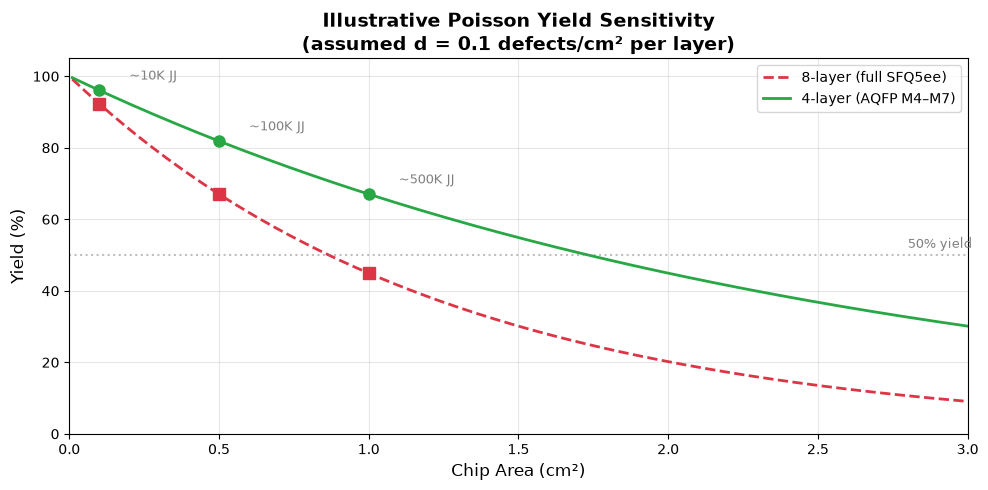

For the same assumed layer-area exposure, fewer layers reduce modeled defect opportunity.
This sensitivity plot does not predict actual SFQ5ee or AQFP yield.
Illustrative comparison at 0.5 cm²:
  8-layer: 67% yield
  4-layer: 82% yield


In [1]:
# Yield vs. Chip Area visualization — area-based defect model
import matplotlib.pyplot as plt
import numpy as np

# Illustrative input for teaching the Poisson model; not a foundry measurement
d = 0.1  # assumed defects/cm² per layer

areas = np.linspace(0.01, 3.0, 200)  # chip area in cm²

fig, ax = plt.subplots(figsize=(10, 5))

for L, color, ls in [(8, '#dc3545', '--'), (4, '#28a745', '-')]:
    Y = 100 * np.exp(-d * L * areas)
    ax.plot(areas, Y, color=color, linewidth=2, linestyle=ls,
            label=f'{L}-layer ({"full SFQ5ee" if L == 8 else "AQFP M4–M7"})')

# Mark some reference die sizes
for area, label in [(0.1, '~10K JJ'), (0.5, '~100K JJ'), (1.0, '~500K JJ')]:
    y4 = 100 * np.exp(-d * 4 * area)
    y8 = 100 * np.exp(-d * 8 * area)
    ax.plot(area, y4, 'o', color='#28a745', markersize=8, zorder=5)
    ax.plot(area, y8, 's', color='#dc3545', markersize=8, zorder=5)
    ax.annotate(label, xy=(area, y4), xytext=(area + 0.1, y4 + 3),
                fontsize=9, color='gray')

ax.axhline(50, color='gray', linestyle=':', alpha=0.5)
ax.text(2.8, 52, '50% yield', fontsize=9, color='gray')

ax.set_xlabel('Chip Area (cm²)', fontsize=12)
ax.set_ylabel('Yield (%)', fontsize=12)
ax.set_title('Illustrative Poisson Yield Sensitivity\n(assumed d = 0.1 defects/cm² per layer)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 3.0)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("For the same assumed layer-area exposure, fewer layers reduce modeled defect opportunity.")
print('This sensitivity plot does not predict actual SFQ5ee or AQFP yield.')
print("Illustrative comparison at 0.5 cm²:")
print(f"  8-layer: {100*np.exp(-d*8*0.5):.0f}% yield")
print(f"  4-layer: {100*np.exp(-d*4*0.5):.0f}% yield")

### Test Structures

Process monitoring uses dedicated test structures on each wafer:

| Structure | Measurement | Purpose |
|-----------|-------------|--------|
| Van der Pauw | Sheet resistance | Film quality |
| Kelvin | Contact resistance | Via quality |
| JJ arrays | Ic distribution | Junction uniformity |

```
 Van der Pauw Structure              Kelvin Contact Structure

       1 ●─────────● 2               I+ ●─────┬─────● V+
         │         │                          │
         │         │                    ┌─────┴─────┐
         │         │                    │    Via    │
         │         │                    └─────┬─────┘
       4 ●─────────● 3               I─ ●─────┴─────● V─

   Rsh = (π/ln2) × V₃₄/I₁₂          Rvia = V/I (4-wire)
```

**Van der Pauw**: Measures sheet resistance independent of sample geometry. Current flows 1→2, voltage measured 3→4.

**Kelvin contact**: Four-wire measurement eliminates lead resistance, giving true via/contact resistance.

---
## Summary
- **Niobium** is the primary superconductor, deposited by DC sputtering (~0.54 nm/s at 500W, 4 mTorr Ar)
- **SFQ5ee provides eight superconducting metal layers**; M4/M7 ground planes and M5/M6 signals form one useful stripline subset
- **Ground planes must be continuous** under active components - gaps cause EM issues
- **Nb/Al-AlOx/Nb trilayer** is the standard junction technology with in-situ deposition
- **Jc controlled by oxidation**: P x t determines barrier thickness and critical current density
- **Feature sizes (350 nm - 2 μm)** are much larger than CMOS, enabling DUV (248 nm) lithography
- **Jc uniformity < 3.5% CV** is achievable with modern processes

### Key Process Examples
- **MIT-LL SFQ5ee**: 8 superconducting metal layers, 350 nm min feature, 10 kA/cm², Gov't/Research access
- **AIST ADP2**: 10 layers, 500 nm min feature, 10 kA/cm², Research access
- **SEEQC**: 4-8 layers, 0.5-1 μm min feature, 4.5-10 kA/cm², Commercial access

---
## Check Your Understanding

1. Why must the Nb/Al-AlO$_x$/Nb trilayer be deposited without breaking vacuum?
2. In the illustrative model $Y=e^{-dLA}$, compute yield for $d=0.1$ cm$^{-2}$ layer$^{-1}$, $L=8$, and $A=0.5$ cm$^2$. Which assumptions limit the conclusion?
3. Name two measurements that separate barrier nonuniformity from lithographic area variation.

<div style="background: linear-gradient(135deg, #0c2340 0%, #7c5cff 100%); color: white; padding: 24px; border-radius: 12px; margin-top: 28px;">
<strong>Lecture 8 complete</strong><br>
<span>Process capability is established by measured uniformity, test structures, and operating circuits.</span>
</div>

<div style="display: flex; justify-content: center; gap: 0.6rem; flex-wrap: wrap; margin: 18px 0 4px;">
[← Previous: 7. Circuit Design and Integration](../07_circuit_design_integration/) &nbsp;|&nbsp; [Course home](../../) &nbsp;|&nbsp; [Next: 9. Packaging and I/O →](../09_packaging_io/)
</div>